# Hometask 
1) Classify the signs (fingers)  dataset 
2) Try to change the number of hidden layer 
3) Change the activation to tanh or sigmoid and see what happens
4) Change the dropout ratio and check the performance

Use simple linear model for this HW
- **Model architecture**: `Dense -> BN -> Activation -> Dropout`


## Step 1 — Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

import os
os.environ["KERAS_BACKEND"] = "torch"

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from keras.callbacks import EarlyStopping

from pathlib import Path

data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("lesson_18_tensorflow_keras") / "data"

In [2]:
def load_dataset(base_path):
    
    fn = base_path / 'train_signs.h5'
    train_dataset = h5py.File(fn, 'r')
    X_train  = np.array(train_dataset['train_set_x'][:])
    Y_train  = np.array(train_dataset['train_set_y'][:])

    fn = base_path / 'test_signs.h5'
    test_dataset = h5py.File(fn, 'r')
    X_test   = np.array(test_dataset['test_set_x'][:])
    Y_test   = np.array(test_dataset['test_set_y'][:])

    classes  = np.array(test_dataset['list_classes'][:])

    Y_train  = Y_train.reshape((1, Y_train.shape[0]))
    Y_test   = Y_test.reshape((1, Y_test.shape[0]))

    return X_train, Y_train, X_test, Y_test, classes

train_data, train_labels, test_data, test_labels, classes = load_dataset(data_dir)

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)


train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


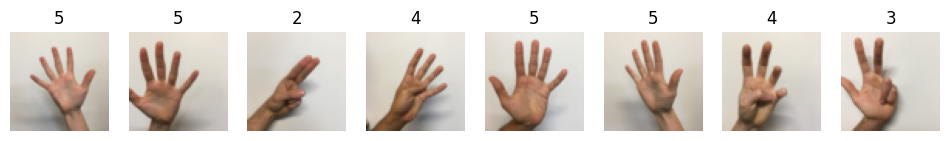

In [3]:
plt.figure(figsize=(12, 3))
for i in range(8):
    idx = np.random.randint(0, len(train_data))
    plt.subplot(1, 8, i+1)
    plt.imshow(train_data[idx])
    plt.title(int(train_labels[0][idx]))
    plt.axis('off')
plt.show()


## Preprocess

In [4]:
train_data_s = train_data / 255.0
test_data_s = test_data  / 255.0

X_train_display = train_data_s
X_test_display = test_data_s

dim = np.prod(train_data.shape[1:])
X_train = train_data_s.reshape(train_data_s.shape[0], dim)
X_test = test_data_s.reshape(test_data_s.shape[0],  dim)

n_classes = len(classes)
y_train = to_categorical(train_labels[0], n_classes)
y_test = to_categorical(test_labels[0],  n_classes)

print(f'dim={dim}, n_classes={n_classes}')
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

dim=12288, n_classes=6
X_train: (1080, 12288)
X_test: (120, 12288)
y_train: (1080, 6)
y_test: (120, 6)


## Helper Functions

In [5]:
def plot_curves(history, title=''):
    
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    
    ax[0].plot(history.history['loss'], 'r', linewidth=3.0, label='Training Loss')
    ax[0].plot(history.history['val_loss'], 'b', linewidth=3.0, label='Validation Loss')
    ax[0].set_title(f'Loss Curves {title}', fontsize=16)
    ax[0].set_xlabel('Epochs', fontsize=16)
    ax[0].set_ylabel('Loss', fontsize=16)
    ax[0].legend(fontsize=18)
    
    ax[1].plot(history.history['accuracy'], 'r', linewidth=3.0, label='Training Accuracy')
    ax[1].plot(history.history['val_accuracy'], 'b', linewidth=3.0, label='Validation Accuracy')
    ax[1].set_title(f'Accuracy Curves {title}', fontsize=16)
    ax[1].set_xlabel('Epochs', fontsize=16)
    ax[1].set_ylabel('Accuracy', fontsize=16)
    ax[1].legend(fontsize=18)
    
    plt.tight_layout()
    plt.show()

def evaluate(model, label=''):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'{label}  ->  Test Loss: {loss:.4f}; Test Accuracy: {acc:.4f}')
    return acc

In [6]:
def plot_predictions(model, X_display, X_input, y_true_oh, class_names=None, nrow=2, ncol=10, num_samples=20, title="Model Predictions"):
    # Select random unique indices
    indices = np.random.choice(len(X_display), num_samples, replace=False)
    # Extract the inputs for the selected indices and predict
    selected_inputs = X_input[indices]
    preds = model.predict(selected_inputs, verbose=0)
    y_pred = np.argmax(preds, axis=1)  # Convert softmax probabilities to class indices
    # Setup the matplotlib grid
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 2.5, nrow * 3.5))
    fig.suptitle(title, fontsize=14)
    # Ensure axes is iterable even if its a 1D grid
    if nrow == 1 or ncol == 1:
        axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes.flat):
        if i < num_samples:
            idx = indices[i]
            img = X_display[idx]
            # Extract true label from the one-hot encoded array
            true_label = np.argmax(y_true_oh[idx])
            pred_label = y_pred[i]
            # Format text
            true_text = class_names[true_label] if class_names is not None else true_label
            pred_text = class_names[pred_label] if class_names is not None else pred_label
            # green if prediction matches true label, red if not
            color = 'green' if pred_label == true_label else 'red'
            ax.imshow(img)
            ax.set_title(f'True: {true_text}\nPred: {pred_text}', color=color, fontsize=11, fontweight='bold')
            ax.axis('off')
    fig.tight_layout()
    plt.show()

---
## Base model

```
Dense(128) → BatchNorm → ReLU → Dropout(0.3)
Dense(64)  → BatchNorm → ReLU → Dropout(0.3)
Dense(6, softmax)
```
each block = **one** Dense + BatchNorm + Activation + Dropout

**Validation jumping**  
The test set has only 120 samples.
With such a small set, validation metrics are expected to be noisy.


In [29]:
model_1 = Sequential([
    Input(shape=(dim,)),
    # Block 1: Dense -> BN -> ReLU -> Dropout
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    # Block 2: Dense -> BN -> ReLU -> Dropout
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    # Output
    Dense(n_classes, activation='softmax')
], name ='model_1')

model_1.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_1.summary()

early_stop = EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        mode='max',
        restore_best_weights=True,
        start_from_epoch = 20
    )

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,582,406 (6.04 MB)

 Trainable params: 1,582,022 (6.03 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4434 - loss: 1.4529 - val_accuracy: 0.1944 - val_loss: 10.1199
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6451 - loss: 0.9717 - val_accuracy: 0.1574 - val_loss: 8.2026
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7510 - loss: 0.7550 - val_accuracy: 0.2037 - val_loss: 7.1157
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7932 - loss: 0.6403 - val_accuracy: 0.3426 - val_loss: 4.3120
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8549 - loss: 0.4981 - val_accuracy: 0.3611 - val_loss: 2.5384
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8879 - loss: 0.4275 - val_accuracy: 0.2870 - val_loss: 3.5773
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8807 - loss: 0.4052 - val_accuracy: 0.4259 - val_loss: 2.7043
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9146 - loss: 0.3301 - val_accuracy: 0

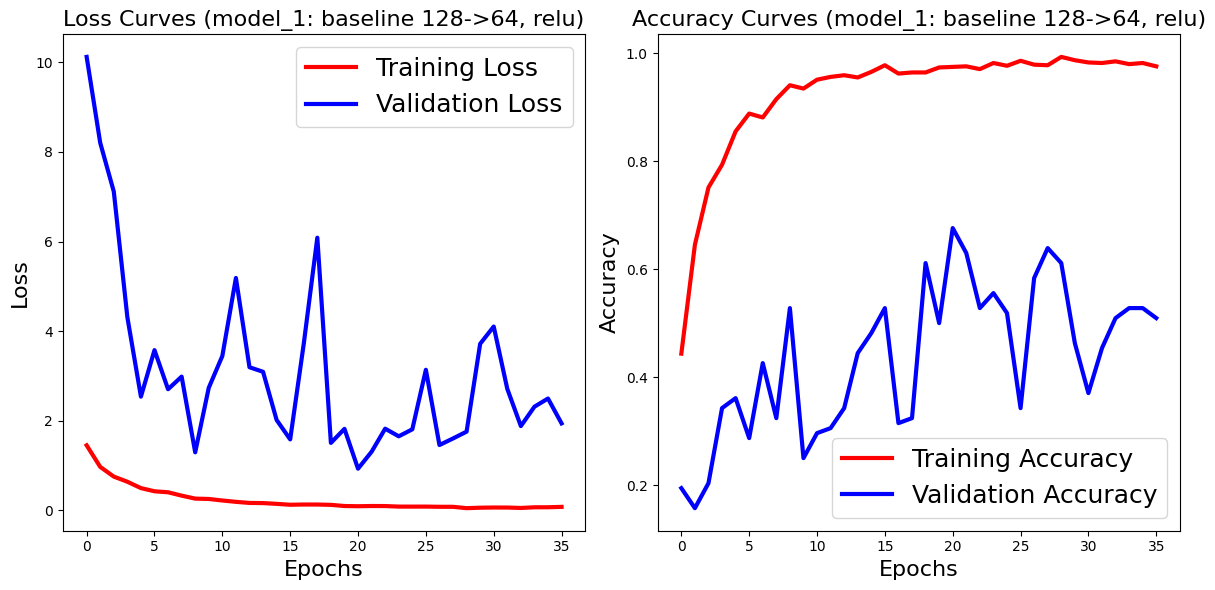

model_1  ->  Test Loss: 0.8277; Test Accuracy: 0.7417


In [30]:
history_1 = model_1.fit(
    X_train, y_train,
    batch_size=32, epochs=100, verbose=1,
    validation_split=0.1,
    callbacks=[early_stop]
)

plot_curves(history_1, title='(model_1: baseline 128->64, relu)')
acc_1 = evaluate(model_1, 'model_1')


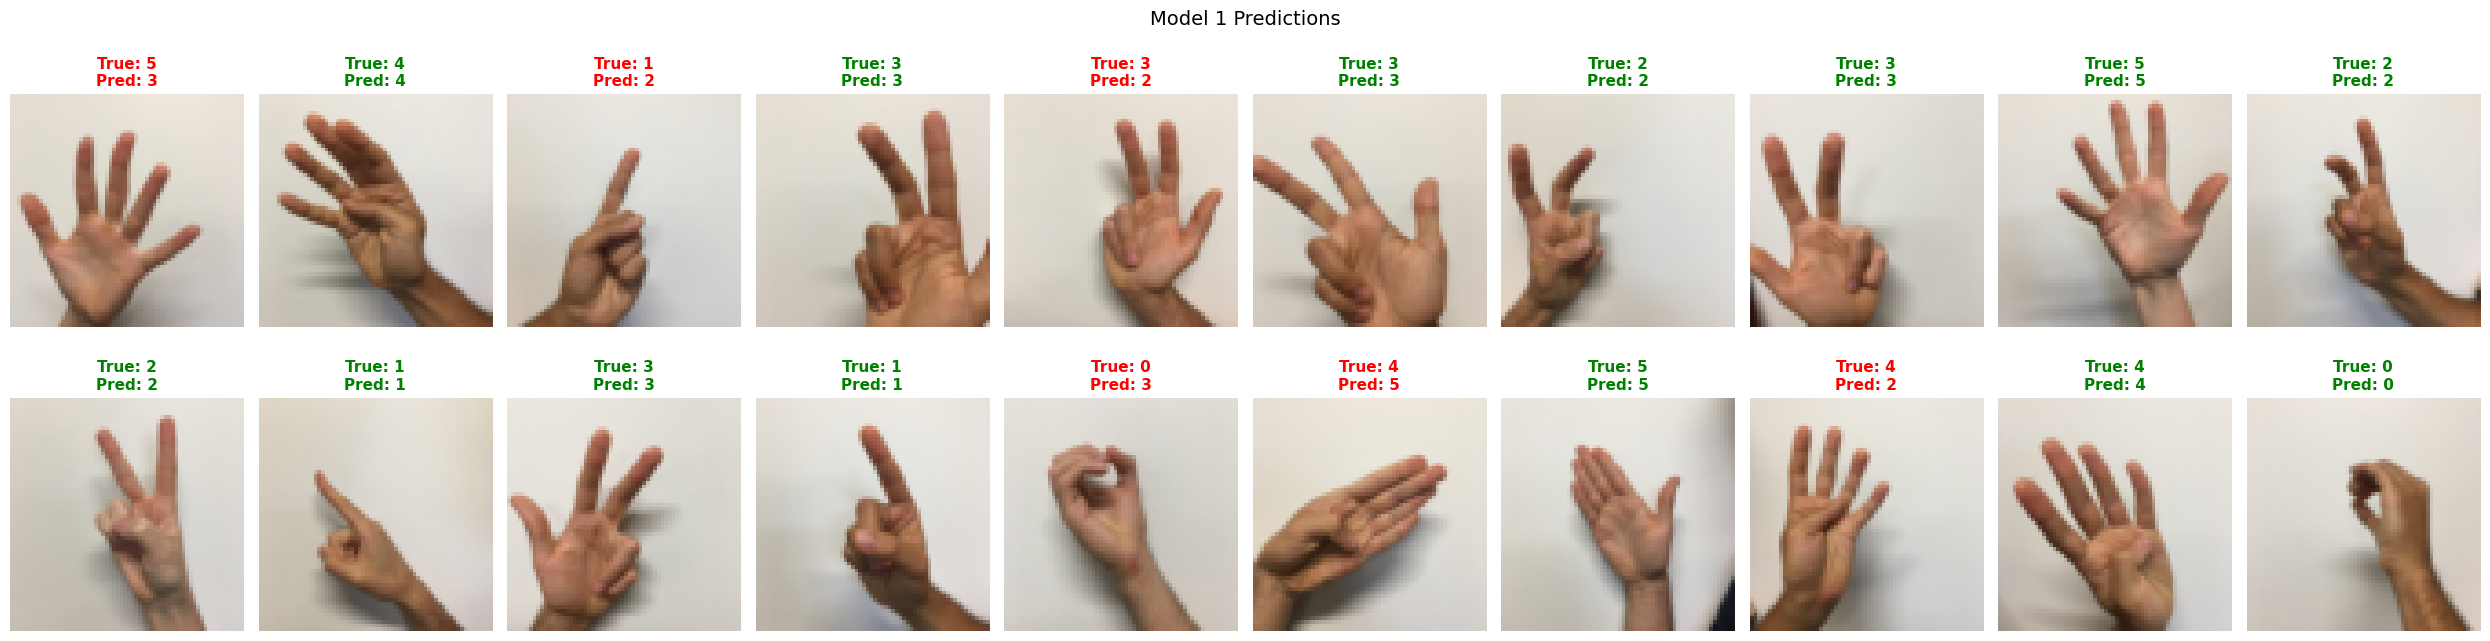

In [31]:
# To test the model on 10 random samples (2 rows, 5 columns)
plot_predictions(
    model=model_1,
    X_display=X_test_display, 
    X_input=X_test, # The flattened features for model.predict
    y_true_oh=y_test,  # The one-hot encoded test labels
    title="Model 1 Predictions"
)

## Add a hidden layer

Add a third `Dense(32)` block.  
More layers mean more parameters and a higher overfitting risk on a small dataset.

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,584,422 (6.04 MB)

 Trainable params: 1,583,974 (6.04 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3093 - loss: 1.7210 - val_accuracy: 0.1667 - val_loss: 11.6274
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4463 - loss: 1.3573 - val_accuracy: 0.1667 - val_loss: 9.9046
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5731 - loss: 1.1774 - val_accuracy: 0.1667 - val_loss: 7.9527
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6167 - loss: 1.0694 - val_accuracy: 0.2167 - val_loss: 6.5557
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6870 - loss: 0.9108 - val_accuracy: 0.4083 - val_loss: 2.3607
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7370 - loss: 0.8005 - val_accuracy: 0.4083 - val_loss: 1.9550
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8028 - loss: 0.6799 - val_accuracy: 0.5000 - val_loss: 1.4785
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7972 - loss: 0.6519 - val_accuracy: 0.6417 - 

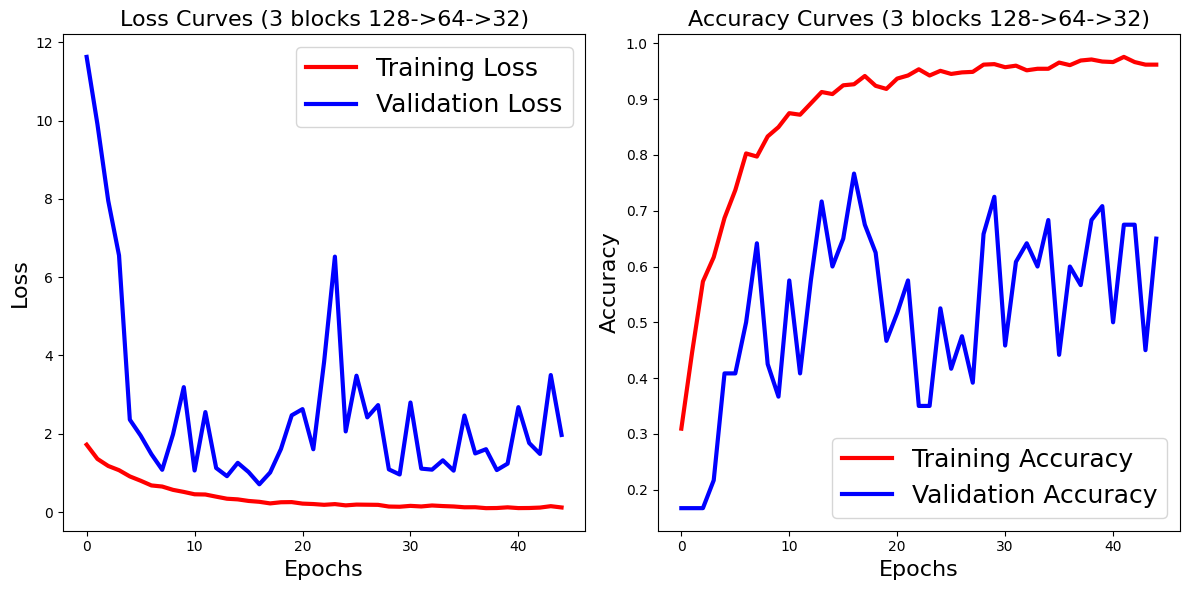

model_2  ->  Test Loss: 0.9593; Test Accuracy: 0.7250


In [32]:
model_2 = Sequential([
    Input(shape=(dim,)),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(32), # new block with 32 neurons
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(n_classes, activation='softmax')
])

model_2.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_2.summary()

history_2 = model_2.fit(
    X_train, y_train,
    batch_size=32, epochs=50, verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

plot_curves(history_2, title='(3 blocks 128->64->32)')
acc_2 = evaluate(model_2, 'model_2')


## model 3: change activation on tanh

- `relu` outputs values from 0 to infinity and usually trains quickly
- `tanh` outputs values from -1 to 1, is symmetric, and is more prone to vanishing gradients


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,582,406 (6.04 MB)

 Trainable params: 1,582,022 (6.03 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5194 - loss: 1.2849 - val_accuracy: 0.2417 - val_loss: 4.2855
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7120 - loss: 0.8181 - val_accuracy: 0.2417 - val_loss: 3.5337
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7898 - loss: 0.5922 - val_accuracy: 0.3250 - val_loss: 2.4100
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8704 - loss: 0.4410 - val_accuracy: 0.5000 - val_loss: 1.3847
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8917 - loss: 0.3602 - val_accuracy: 0.2917 - val_loss: 2.0279
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9111 - loss: 0.3056 - val_accuracy: 0.5250 - val_loss: 1.1709
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9407 - loss: 0.2318 - val_accuracy: 0.2417 - val_loss: 3.8006
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9426 - loss: 0.2047 - val_accuracy: 0.3583 - v

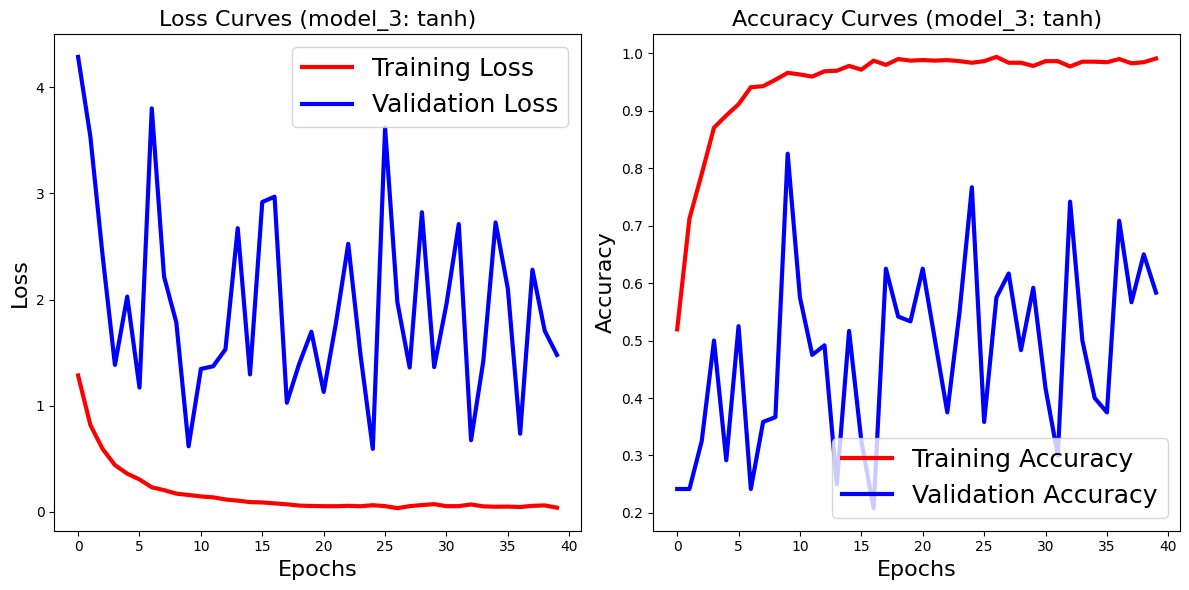

model_3: tanh  ->  Test Loss: 0.5931; Test Accuracy: 0.7667


In [34]:
model_3 = Sequential([
    Input(shape=(dim,)),
    Dense(128),
    BatchNormalization(),
    Activation('tanh'), # tanh instead of relu 
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('tanh'),
    Dropout(0.3),

    Dense(n_classes, activation='softmax')
])

model_3.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_3.summary()

history_3 = model_3.fit(
    X_train, y_train,
    batch_size=32, epochs=50, verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

plot_curves(history_3, title='(model_3: tanh)')
acc_3 = evaluate(model_3, 'model_3: tanh')


## model 3b — Activation(sigmoid)

- `sigmoid` outputs values from 0 to 1 and is the most prone to vanishing gradients


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_36 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,582,406 (6.04 MB)

 Trainable params: 1,582,022 (6.03 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3806 - loss: 1.5661 - val_accuracy: 0.1750 - val_loss: 1.9180
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5556 - loss: 1.2676 - val_accuracy: 0.1833 - val_loss: 1.8920
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6306 - loss: 1.1311 - val_accuracy: 0.3750 - val_loss: 1.5850
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6963 - loss: 0.9933 - val_accuracy: 0.2667 - val_loss: 1.6475
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7509 - loss: 0.8909 - val_accuracy: 0.2333 - val_loss: 1.8701
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7713 - loss: 0.7918 - val_accuracy: 0.2917 - val_loss: 1.6733
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7935 - loss: 0.7466 - val_accuracy: 0.3167 - val_loss: 2.0587
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8435 - loss: 0.6531 - val_accuracy: 0.2167 - v

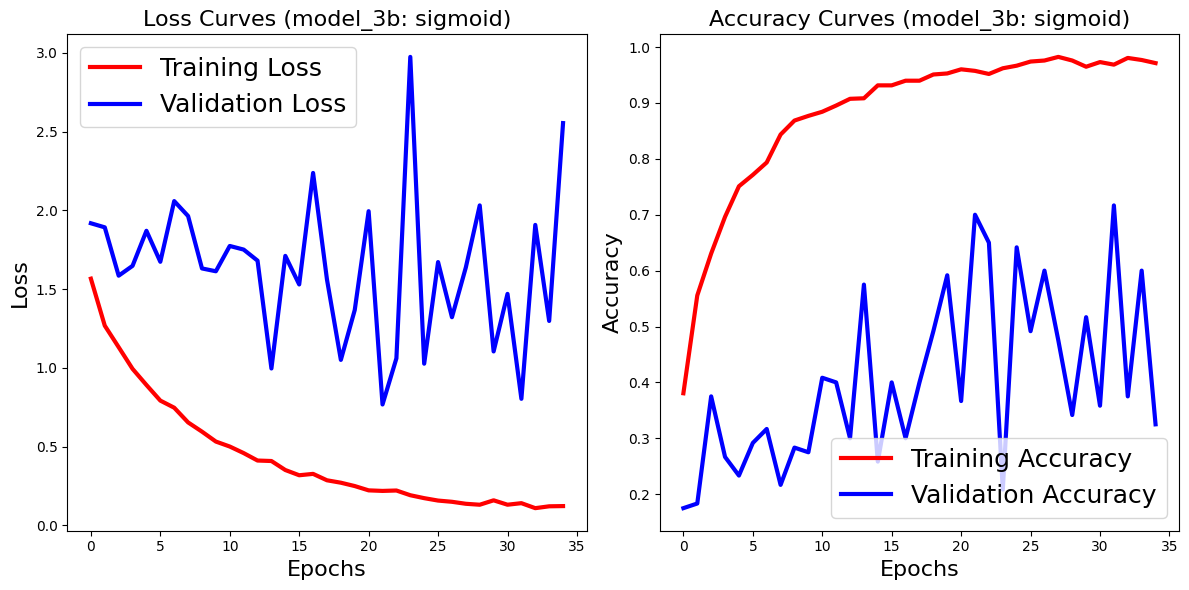

model_3b: sigmoid  ->  Test Loss: 1.9945; Test Accuracy: 0.3667


In [35]:
model_3b = Sequential([
    Input(shape=(dim,)),
    Dense(128),
    BatchNormalization(),
    Activation('sigmoid'), # sigmoid instead of relu
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('sigmoid'),
    Dropout(0.3),

    Dense(n_classes, activation='softmax')
])

model_3b.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

model_3b.summary()

history_3b = model_3b.fit(
    X_train, y_train,
    batch_size=32, epochs=50, verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

plot_curves(history_3b, title='(model_3b: sigmoid)')
acc_3b = evaluate(model_3b, 'model_3b: sigmoid')


## model 4 — Dropout ratio 

Dropout turns off a fraction `p` of neurons during training:
- **0.2** means lighter regularization, so the model may train faster but can overfit
- **0.5** means stronger regularization, so train and validation curves may stay closer


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,582,406 (6.04 MB)

 Trainable params: 1,582,022 (6.03 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5046 - loss: 1.3276 - val_accuracy: 0.1667 - val_loss: 12.3048
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7565 - loss: 0.8084 - val_accuracy: 0.1750 - val_loss: 10.1220
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8278 - loss: 0.5914 - val_accuracy: 0.3167 - val_loss: 8.0474
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9083 - loss: 0.4195 - val_accuracy: 0.2917 - val_loss: 5.1937
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9074 - loss: 0.3529 - val_accuracy: 0.3250 - val_loss: 3.8868
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9306 - loss: 0.2726 - val_accuracy: 0.4083 - val_loss: 2.3726
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9620 - loss: 0.2187 - val_accuracy: 0.4667 - val_loss: 2.9999
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9676 - loss: 0.1745 - val_accuracy: 0.5000 -

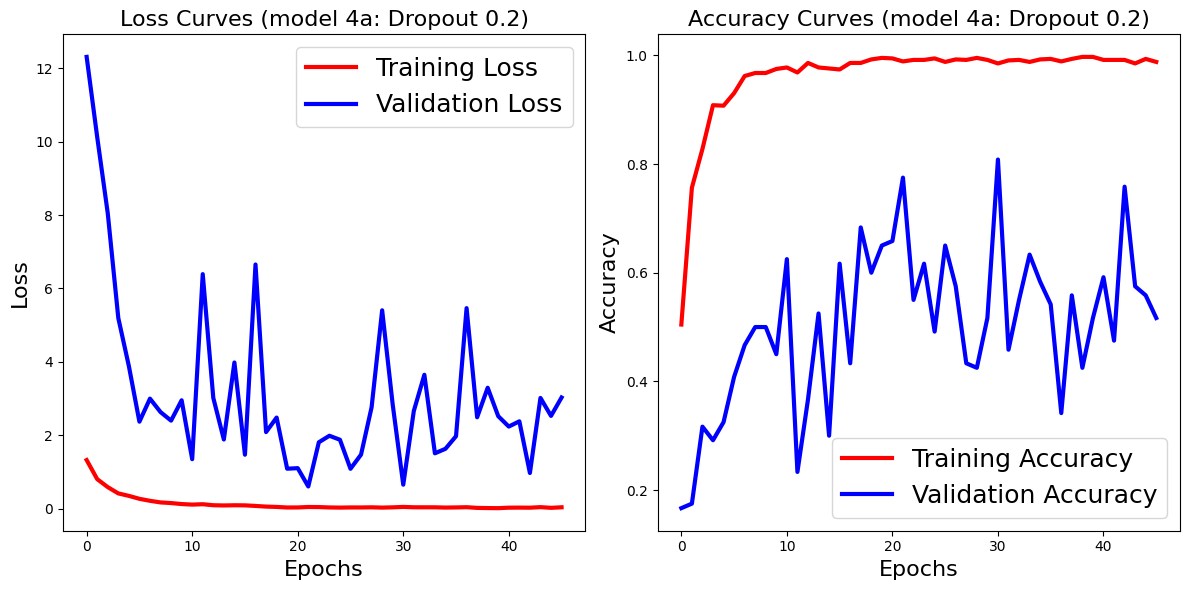

model_4a: Dropout 0.2  ->  Test Loss: 0.6577; Test Accuracy: 0.8083


In [36]:
# Dropout 0.2
model_4a = Sequential([
    Input(shape=(dim,)),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),# lighter regularization

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.2),

    Dense(n_classes, activation='softmax')
])

model_4a.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

model_4a.summary()

history_4a = model_4a.fit(
    X_train, y_train,
    batch_size=32, epochs=50, verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

plot_curves(history_4a, title='(model 4a: Dropout 0.2)')
acc_4a = evaluate(model_4a, 'model_4a: Dropout 0.2')


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,582,406 (6.04 MB)

 Trainable params: 1,582,022 (6.03 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2824 - loss: 1.9813 - val_accuracy: 0.2333 - val_loss: 9.1882
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4537 - loss: 1.4208 - val_accuracy: 0.2250 - val_loss: 6.8104
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5574 - loss: 1.1469 - val_accuracy: 0.2167 - val_loss: 6.0438
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6167 - loss: 1.0078 - val_accuracy: 0.3000 - val_loss: 4.2012
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6870 - loss: 0.8727 - val_accuracy: 0.3417 - val_loss: 4.8797
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7093 - loss: 0.8316 - val_accuracy: 0.2083 - val_loss: 4.5269
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7417 - loss: 0.7293 - val_accuracy: 0.3000 - val_loss: 2.3522
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7593 - loss: 0.6839 - val_accuracy: 0.4417 - v

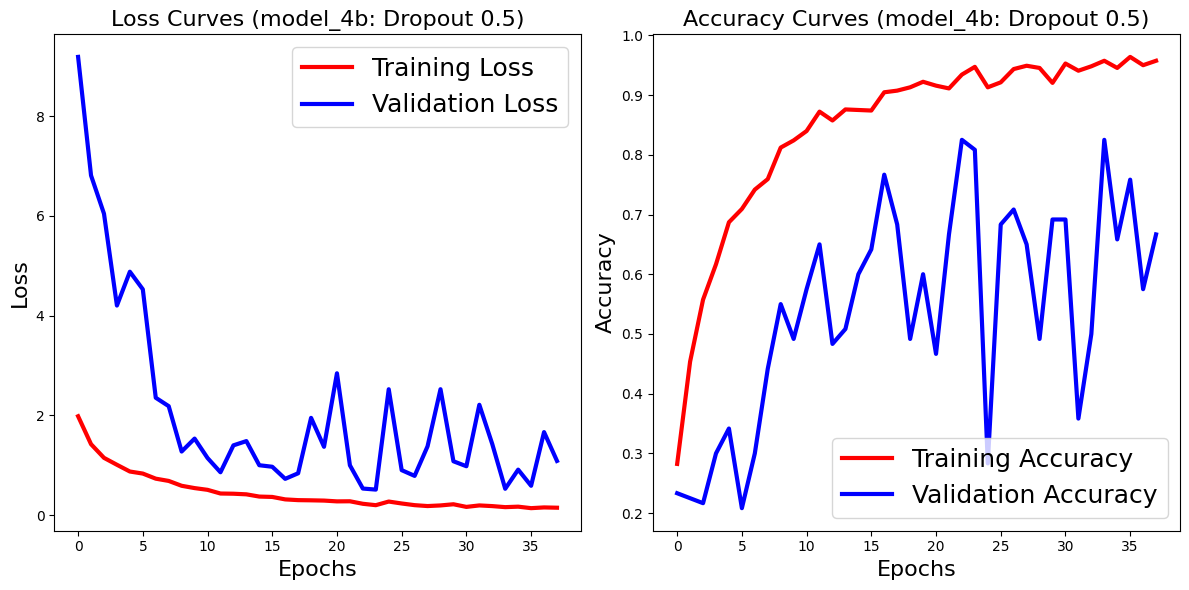

model_4b: Dropout 0.5  ->  Test Loss: 0.5312; Test Accuracy: 0.8250


In [37]:
model_4b = Sequential([
    Input(shape=(dim,)),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),# stronger regularization

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(n_classes, activation='softmax')
])

model_4b.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

model_4b.summary()

history_4b = model_4b.fit(
    X_train, y_train,
    batch_size=32, epochs=50, verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

plot_curves(history_4b, title='(model_4b: Dropout 0.5)')
acc_4b = evaluate(model_4b, 'model_4b: Dropout 0.5')


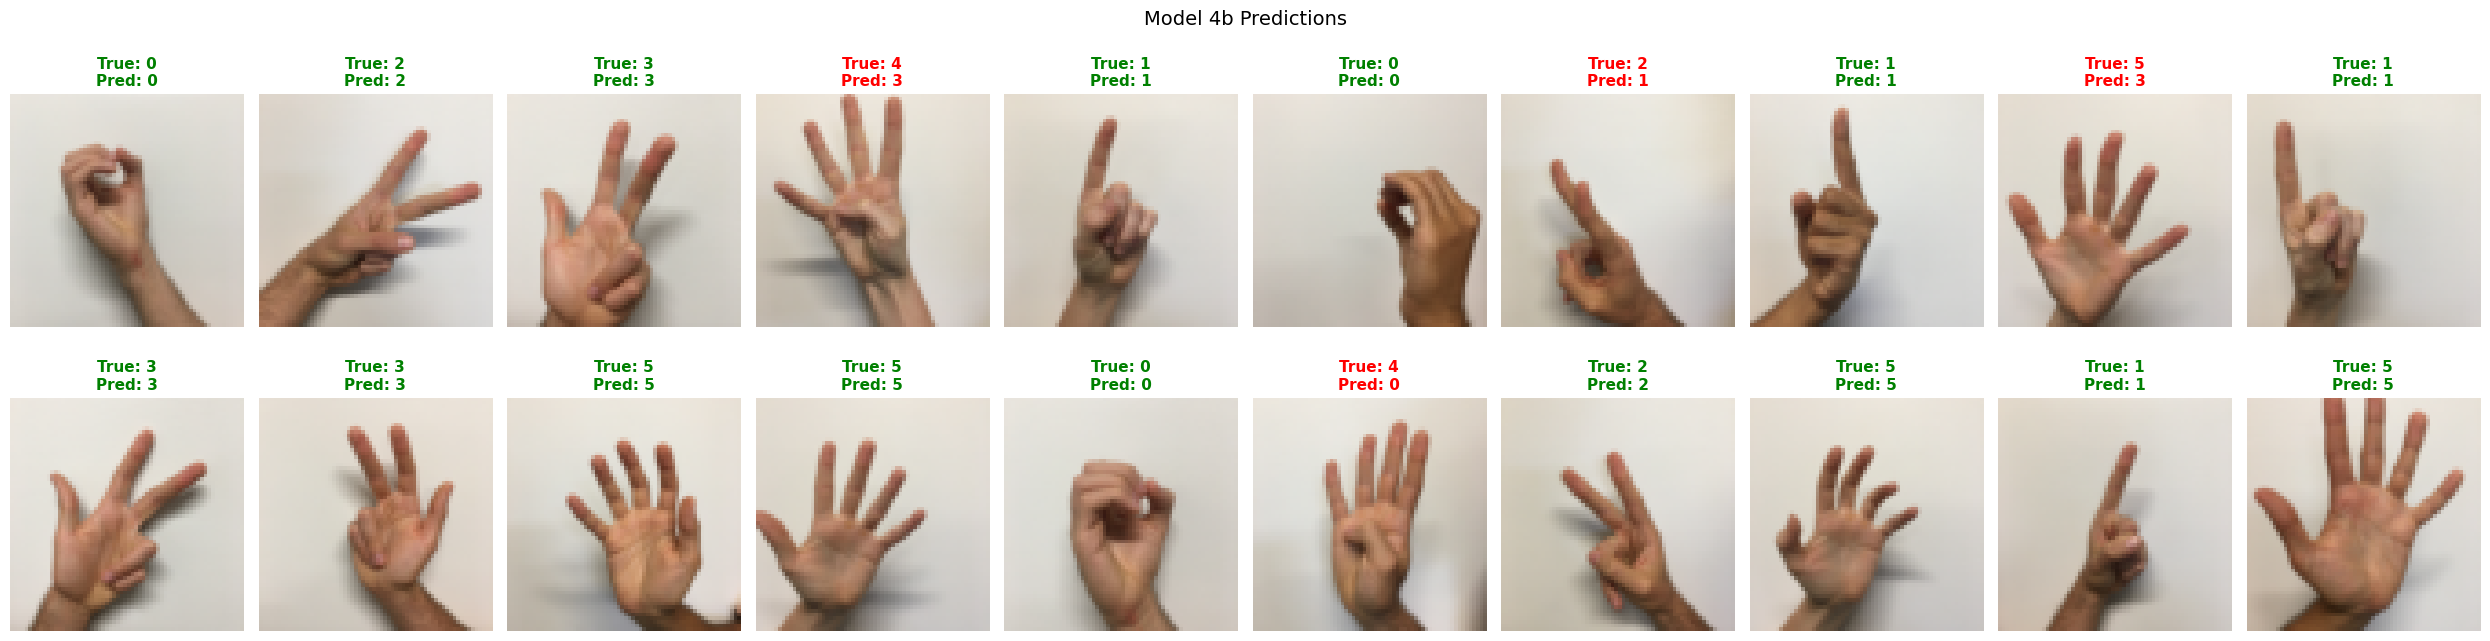

In [38]:
plot_predictions(
    model=model_4b, 
    X_display=X_test_display, # The 2D/3D images for plt.imshow
    X_input=X_test, # The flattened features for model.predict
    y_true_oh=y_test, # The one-hot encoded test labels
    title="Model 4b Predictions"
)

---
## Conclusion

In [39]:
print(f'{"Model":<50} {"Test Acc":>12}')
print(f'{"model 1 — baseline (128->64, relu, drop=0.3)":<50} {acc_1:>12.4f}')
print(f'{"model 2 — 3 blocks (128->64->32)":<50} {acc_2:>12.4f}')
print(f'{"model 3 — tanh activation":<50} {acc_3:>12.4f}')
print(f'{"model 3b — sigmoid activation":<50} {acc_3b:>12.4f}')
print(f'{"model 4a — Dropout 0.2":<50} {acc_4a:>12.4f}')
print(f'{"model 4b — Dropout 0.5":<50} {acc_4b:>12.4f}')


Model                                                  Test Acc
model 1 — baseline (128->64, relu, drop=0.3)             0.7417
model 2 — 3 blocks (128->64->32)                         0.7250
model 3 — tanh activation                                0.7667
model 3b — sigmoid activation                            0.3667
model 4a — Dropout 0.2                                   0.8083
model 4b — Dropout 0.5                                   0.8250


### Result Analysis

The results are noisy because the test set has only 120 samples. In this run, the best test accuracy came from the model with `Dropout(0.5)`. The extra hidden layer did not improve the result, so a larger model is not automatically better for this small dataset.

`tanh` and `sigmoid` worked worse than the best relu-based model. This is expected because both activations are more prone to vanishing gradients. Overall, relu with a carefully chosen dropout value is the most practical choice here.
